# Сборный проект № 1

Анализ данных интернет-магазина «Стримчик», который продаёт по всему миру компьютерные игры

В интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры имеются некоторые данные. 

Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Мы постараемя выявить определяющие успешность игры закономерности. 
Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

Нам предоставлены данные до 2016 года. Нам необходимы попытаться спланировать кампанию на 2017-й. Нужно отработать принцип работы с данными. 

В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

# План действий

Шаг 1. Открыть файл с данными и изучить общую информацию

Шаг 2. Подготовить данные

* Заменить названия столбцов;
* Преобразовать данные в нужные типы;
* Обработать пропуски при необходимости; 
    * Объяснить причины, которые могли привести к пропускам;
    * Обратить внимание на аббревиатуру 'tbd' в столбце с оценкой пользователей. 
    Отдельно разобрать это значение и описать, как его обработать;
* Посчитать суммарные продажи во всех регионах и записать их в отдельный столбец;
* Поискать явные и неявные дубликаты.

Шаг 3. Провести исследовательский анализ данных
* Посмотреть, сколько игр выпускалось в разные годы. Важны ли данные за все периоды? (вопрос от заказчика)
* Посмотреть, как менялись продажи по платформам. Выбрать платформы с наибольшими суммарными продажами и построить распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы? (задача от заказчика)
* Взять данные за соответствующий актуальный период. Актуальный период определить самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год. (задача от заказчика)
Не учитывать в работе данные за предыдущие годы.
* Какие платформы лидируют по продажам, растут или падают? Выберите несколько потенциально прибыльных платформ. (задача от заказчика)
* Построить график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Описать результат.
* Посмотреть, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Построить диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулировать выводы.
* Соотнести выводы с продажами игр на других платформах.
* Посмотреть на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами? (вопросы от заказчика).

Шаг 4. Составить портрет пользователя каждого региона
* Определить для пользователя каждого региона (NA, EU, JP):
* Самые популярные платформы (топ-5). Описать различия в долях продаж.
* Самые популярные жанры (топ-5). Пояснить разницу.
* Влияет ли рейтинг ESRB на продажи в отдельном регионе? (задачи от заказчика).

Шаг 5. Проверить гипотезы
* Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
* Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.
* Задать самостоятельно пороговое значение alpha.
Пояснить:
* Как вы сформулировали нулевую и альтернативную гипотезы;
* Какой критерий применили для проверки гипотез и почему.

Шаг 6. Написать общий вывод
_______________

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


Отличная практика - расписывать цель и основные этапы своими словами (этот навык очень поможет на фильнальном проекте).
</div>

Описание данных

Name — название игры

Platform — платформа

Year_of_Release — год выпуска

Genre — жанр игры

NA_sales — продажи в Северной Америке (миллионы проданных копий)

EU_sales — продажи в Европе (миллионы проданных копий)

JP_sales — продажи в Японии (миллионы проданных копий)

Other_sales — продажи в других странах (миллионы проданных копий)

Critic_Score — оценка критиков (максимум 100)

User_Score — оценка пользователей (максимум 10)

Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). 
Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.


Данные за 2016 год могут быть неполными.

# Шаг 1. Открыть файл с данными и изучить общую информацию

In [31]:
!pip install missingno
#нужно установить библиотеку (раскомменниторовать и выполнить учейку)

In [103]:
import pandas as pd
import matplotlib.pyplot as plt 
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

In [137]:
data = pd.read_csv('/datasets/games.csv')
data.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [138]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [139]:
data.duplicated().sum() # полных дублей нет и это хорошо

0

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


Проверка на дубликаты - основа предобработки данных

In [140]:
data.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

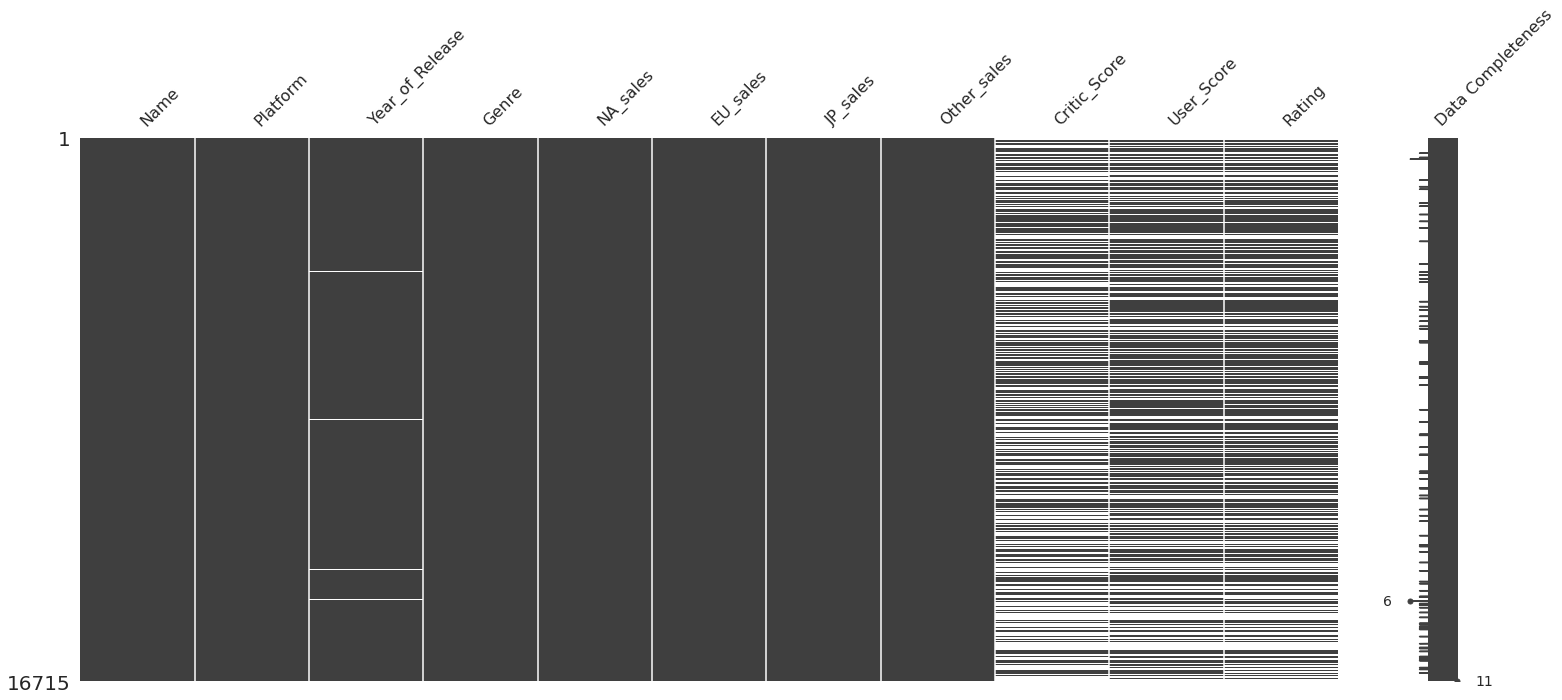

In [141]:
msno.matrix(data, labels=True)
plt.show()

Вывод:

Наблюдаем пропуски, неверные типы данных в некторых колонках, которые следующим шагом будем исправлять
___________

# Шаг 2. Подготовить данные

* Заменить названия столбцов;
* Преобразовать данные в нужные типы;
* Обработать пропуски при необходимости; 
    * Объяснить причины, которые могли привести к пропускам;
    * Обратить внимание на аббревиатуру 'tbd' в столбце с оценкой пользователей. 
    Отдельно разобрать это значение и описать, как его обработать;
* Посчитать суммарные продажи во всех регионах и записать их в отдельный столбец.
* Поискать явные и неявные дубликаты.
______________

In [142]:
data.columns = data.columns.str.lower() #приводим к нижнему регистру
data.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


Молодец, что используешь этот метод

In [143]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [144]:
data.head(1)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E


In [145]:
# Изменим тип данных
data['year_of_release'] = data['year_of_release'].astype('Int64')

In [146]:
#data['user_score'] = data['user_score'].astype(float) разбираемся почему данные не меняются
data['user_score'].unique()
# среди чисел есть слово

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [147]:
data['user_score'] = data['user_score'].replace('tbd', pd.NA, regex=True) # меняем слово на пустоту
# разобрались и поменяли тип данных

# Преобразуем колонки в числовой формат (заменяя некорректные значения на NaN)
data['user_score'] = pd.to_numeric(data['user_score'], errors='coerce')

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Верно, tbd по смыслу то же, что и пропуск</div>

In [148]:
data.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [149]:
data['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

Посмотрели уникальные значения в каждой колонке, увидели пропуски и заметили что часть текстовых значений требует приведения к нижнему регистру. Неявные дубли не обнаружены.  

Сделаем цикл, который для выбранных колонок сделает нижний регистр. 

In [150]:
for column in data[['name','platform','genre','rating']]:
    data[column] = data[column].str.lower()

In [151]:
data.isna().sum()
# еще раз взглянем где у нас есть пропуски

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [152]:
data[data['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,madden nfl 2004,ps2,<NA>,sports,4.26,0.26,0.01,0.71,94.0,8.5,e
377,fifa soccer 2004,ps2,<NA>,sports,0.59,2.36,0.04,0.51,84.0,6.4,e
456,lego batman: the videogame,wii,<NA>,action,1.80,0.97,0.00,0.29,74.0,7.9,e10+
475,wwe smackdown vs. raw 2006,ps2,<NA>,fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,space invaders,2600,<NA>,shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,pdc world championship darts 2008,psp,<NA>,sports,0.01,0.00,0.00,0.00,43.0,NaN,e10+
16405,freaky flyers,gc,<NA>,racing,0.01,0.00,0.00,0.00,69.0,6.5,t
16448,inversion,pc,<NA>,shooter,0.01,0.00,0.00,0.00,59.0,6.7,m
16458,hakuouki: shinsengumi kitan,ps3,<NA>,adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [153]:
data['name'].unique()
# имеем пропуски в колонке 'year_of_release' и одновременно есть в колонке 'name' год релиза в некоторых случаях

array(['wii sports', 'super mario bros.', 'mario kart wii', ...,
       'woody woodpecker in crazy castle 5', 'lma manager 2007',
       'haitaka no psychedelica'], dtype=object)

In [154]:
for i in data[data['year_of_release'].isna() == True].index:  
    data['year_of_release'][i] = data.loc[data['name'] == data['name'][i], 'year_of_release'].max()

In [155]:
data.isna().sum() # частично заменили пустоты

name                  2
platform              0
year_of_release     146
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Оставим пустыми колонки с рейтингами и оценками т.к. не будет правильным отсекать эти данные ведь их весьма много и заменять средним или медианой тоже не рационально.

Сравнив строки в пустыми оценками и заполненными, кажется, что по этим записям не проводилась оценка из-за того, что их мало покупали и соответсвенно отзывов было очень мало

In [156]:
data['sum_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']
# Посчитали суммарные продажи во всех регионах и сохранили их в отдельный столбец.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Можно еще вот так: 
    
    df[['na_sales','eu_sales','jp_sales', 'other_sales']].sum(axis = 1)
    
</div>

In [157]:
data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sum_sales
0,wii sports,wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,e,82.54
1,super mario bros.,nes,1985,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,mario kart wii,wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,e,35.52
3,wii sports resort,wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,e,32.77
4,pokemon red/pokemon blue,gb,1996,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


In [158]:
#функция для вывода уникальных значений по всем колонкам
def uniq(data):
    for column in data.columns:
        print('Уникальные значения столбца', column)
        print(data[column].unique())
        
#также фнукция для вывод количеств дублей по каждой колонке        
def dubli(data):
    for column in data.columns:
        print('Количество дубликатов в', column)
        print(data[column].duplicated().sum())

In [159]:
uniq(data) #немного странно, но так тоже можно сделать
#смотрим вручную нет ли пробелов лишних или прочих значков лишних (где это возможно и видно явно)

Уникальные значения столбца name
['wii sports' 'super mario bros.' 'mario kart wii' ...
 'woody woodpecker in crazy castle 5' 'lma manager 2007'
 'haitaka no psychedelica']
Уникальные значения столбца platform
['wii' 'nes' 'gb' 'ds' 'x360' 'ps3' 'ps2' 'snes' 'gba' 'ps4' '3ds' 'n64'
 'ps' 'xb' 'pc' '2600' 'psp' 'xone' 'wiiu' 'gc' 'gen' 'dc' 'psv' 'sat'
 'scd' 'ws' 'ng' 'tg16' '3do' 'gg' 'pcfx']
Уникальные значения столбца year_of_release
<IntegerArray>
[2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010, 2013, 2004,
 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014, 1992, 1997, 1993, 1994,
 1982, 2016, 2003, 1986, 2000, 1995, 1991, 1981, 1987, 1980, 1983, <NA>]
Length: 38, dtype: Int64
Уникальные значения столбца genre
['sports' 'platform' 'racing' 'role-playing' 'puzzle' 'misc' 'shooter'
 'simulation' 'action' 'fighting' 'adventure' 'strategy' nan]
Уникальные значения столбца na_sales
[4.136e+01 2.908e+01 1.568e+01 1.561e+01 1.127e+01 2.320e+01 1.128e+01
 1.396e+01 1.

In [160]:
dubli(data)

Количество дубликатов в name
5155
Количество дубликатов в platform
16684
Количество дубликатов в year_of_release
16677
Количество дубликатов в genre
16702
Количество дубликатов в na_sales
16313
Количество дубликатов в eu_sales
16408
Количество дубликатов в jp_sales
16471
Количество дубликатов в other_sales
16560
Количество дубликатов в critic_score
16632
Количество дубликатов в user_score
16619
Количество дубликатов в rating
16706
Количество дубликатов в sum_sales
15708


Стоит уделить повышенное внимание колонке с назанием игры, наверное, там вероятнее всего могут быть неявные дубликаты

In [161]:
print('Количество уникальных названий до обработки:', len(data['name'].unique()))

Количество уникальных названий до обработки: 11560


In [162]:
data['name'] = (
    data['name']
    .str.lower()  # Приведение к нижнему регистру
    .str.strip()  # Удаление пробелов в начале и конце строки
    .str.replace(r'\s+', ' ', regex=True)  # Замена двойных и лишних пробелов на один
    .str.replace(r'[^\w\s]+$', '', regex=True)  # Удаление знаков препинания в конце строки
)

In [163]:
print('Количество уникальных названий после обработки:', len(data['name'].unique()))
#3 дубля убрали

Количество уникальных названий после обработки: 11557


In [164]:
#интересный способ
#data['initials'] = data['cleaned_name'].str[:3]
#grouped = data.groupby('initials')['cleaned_name'].apply(list)
#grouped

In [165]:
data[data[['name', 'platform','year_of_release']].duplicated(keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sum_sales
604,madden nfl 13,ps3,2012,sports,2.11,0.22,0.00,0.23,83.0,5.5,e,2.56
659,NaN,gen,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN,2.39
1745,sonic the hedgehog,ps3,2006,platform,0.41,0.06,0.04,0.66,43.0,4.1,e10+,1.17
4127,sonic the hedgehog,ps3,2006,platform,0.00,0.48,0.00,0.00,43.0,4.1,e10+,0.48
14244,NaN,gen,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN,0.03
16230,madden nfl 13,ps3,2012,sports,0.00,0.01,0.00,0.00,83.0,5.5,e,0.01


In [136]:
data = data.drop_duplicates(subset=['name', 'platform', 'year_of_release'], keep='first')
data.shape

(16709, 12)

Вывод:
* Названия колонок привели к нижне регистру и привели к формату "змеиного языка";
* Преобразовали данные в нужные типы;
* Обработали пропуски где это логично;
* Объяснили причины, которые могли привести к пропускам (Сравнив строки в пустыми оценками и заполненными, кажется, что по этим записям не проводилась оценка из-за того, что их мало покупали и соответсвенно отзывов было очень мало - удалять не стали);
* Обратили внимание на аббревиатуру 'tbd' в столбце с оценкой пользователей. 
Отдельно разобрались с его обработкой и успешно заменили;
* Посчитали суммарные продажи во всех регионах и записали их в отдельный столбец 'sum_sales'.
* Поискали явные и неявные дубликаты.
Переходим к исследовательскому этапу.
________

# Шаг 3. Провести исследовательский анализ данных
* Посмотреть, сколько игр выпускалось в разные годы. Важны ли данные за все периоды? (вопрос от заказчика)
* Посмотреть, как менялись продажи по платформам. Выбрать платформы с наибольшими суммарными продажами и построить распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы? (задача от заказчика)
* Взять данные за соответствующий актуальный период. Актуальный период определить самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год. (задача от заказчика)
Не учитывать в работе данные за предыдущие годы.
* Какие платформы лидируют по продажам, растут или падают? Выберите несколько потенциально прибыльных платформ. (задача от заказчика)
* Построить график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Описать результат.
* Посмотреть, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Построить диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулировать выводы.
* Соотнести выводы с продажами игр на других платформах.
* Посмотреть на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами? (вопросы от заказчика).

In [64]:
data_years = data.pivot_table(index='year_of_release', values='name', aggfunc='count')

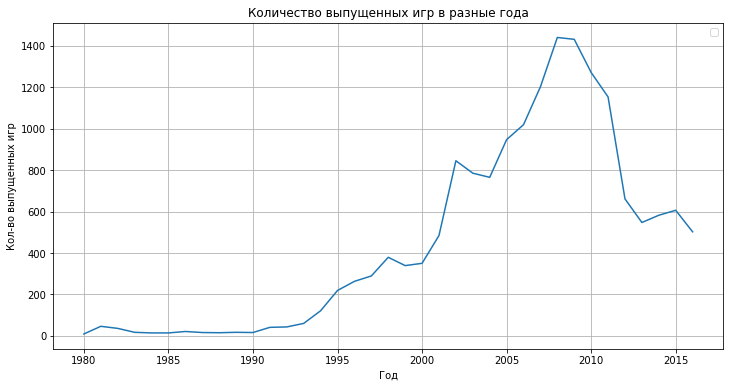

In [65]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data_years)
plt.title("Количество выпущенных игр в разные года")
plt.xlabel("Год")
plt.ylabel("Кол-во выпущенных игр")
plt.legend('')
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Отличная визуализация. При желании можно немного улучшить. Смотри: Для того, чтобы построить графить, нужно сгруппировать данные (в нашем случае год релиза и колличество)
    
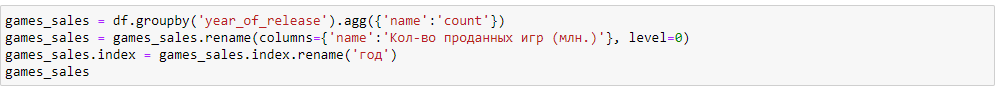
    
---
А потом с помощью библиотеки sns (она мощная, и с ней можно делать всё, что угодно). По данным сгруппированной таблицы строим график. При желании забирай себе =) Главное поиграйся с аргументами и разберись. В дальнейших проектах вы будете строить мощные графики, там пригодится такой навык    
    
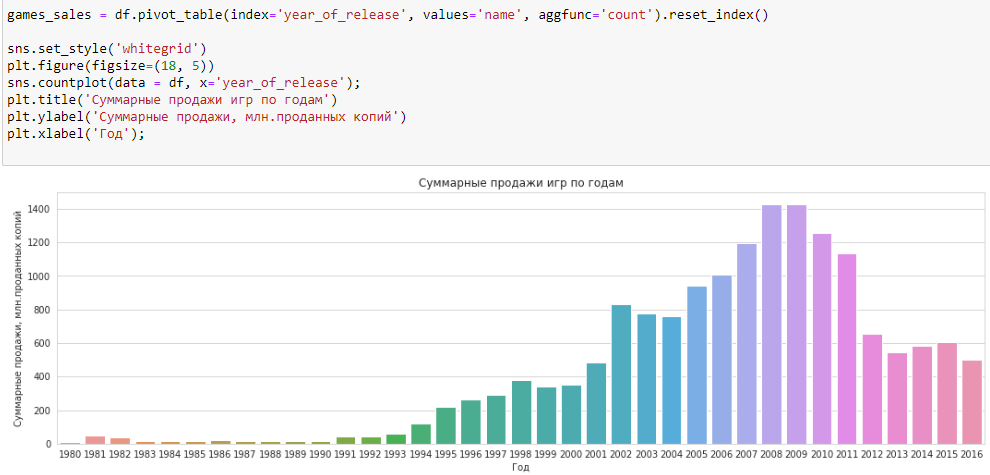  
</div>

Индустрия разработки игр начала активно работать с 1993 года и достигла пика в 2008, затем к 2013 чуть снизилась.
То есть для анализа период до 1993 год не самый информативны, стоит обратить внимание на период с 1993 по 2016 годы. 

In [66]:
data_platforms = data.pivot_table(
    index='platform', values='sum_sales', aggfunc='sum').sort_values(by='sum_sales', ascending=False)

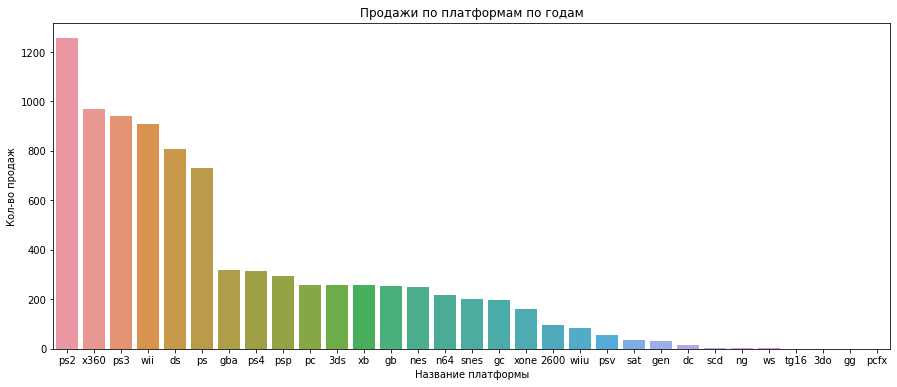

In [67]:
plt.figure(figsize=(15,6))
sns.barplot(x=data_platforms.index,y=data_platforms['sum_sales'])
plt.title("Продажи по платформам по годам")
plt.xlabel("Название платформы")
plt.ylabel("Кол-во продаж")
plt.show()

Самые популярныеплатформы это ps2, x360, ps3, wii, ds, ps

In [68]:
# Функция вывода сводной табл с 1993 года
def year_total_sale_for_platform(name, data):
    return data[(data['platform']==name) & (data['year_of_release']>1993)].pivot_table(
        index='year_of_release', values='sum_sales', aggfunc='sum').sort_values('year_of_release', ascending=False)

In [69]:
top_platforms = data.pivot_table(index='platform', values='sum_sales', aggfunc='sum').sort_values(by='sum_sales', ascending=False).head(5)
top_platforms = top_platforms.reset_index().rename_axis(None, axis=1)
top_platforms

,platform,sum_sales
0,ps2,1255.77
1,x360,971.42
2,ps3,939.16
3,wii,907.51
4,ds,806.12


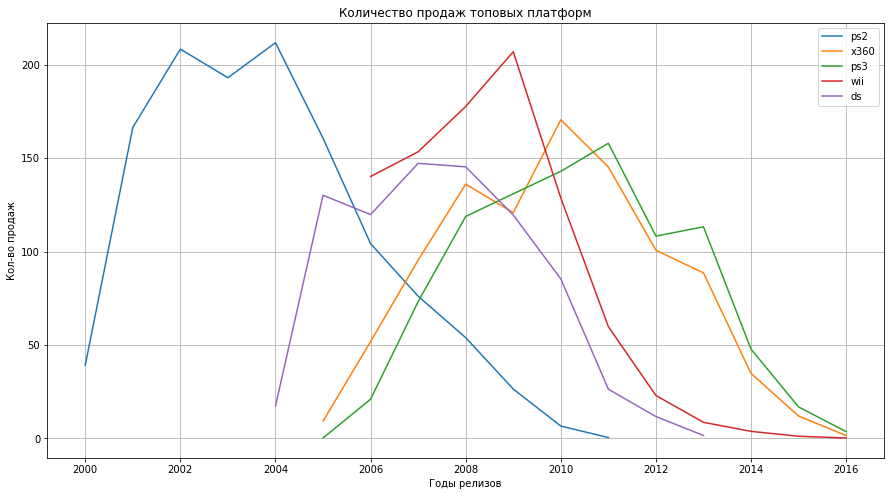

In [70]:
plt.figure(figsize=(15,8))
plt.title('Количество продаж топовых платформ')
plt.xlabel('Годы релизов')
plt.ylabel('Кол-во продаж')
plt.grid(True)

for i in list(top_platforms['platform']):
    sns.lineplot(data=year_total_sale_for_platform(i,data)['sum_sales'], label=i)
    plt.legend()

* Топовые игровые платформы появились в 2006 году. 
* Cамые популярные из них это ps2 и x360
* За 4 года игровые платформы достигают пика продаж

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Согласен, все верно. Здесь еще можно построить тепловую карту
</div>

In [71]:
data.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sum_sales
0,wii sports,wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,e,82.54
1,super mario bros,nes,1985,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,mario kart wii,wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,e,35.52
3,wii sports resort,wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,e,32.77
4,pokemon red/pokemon blue,gb,1996,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
5,tetris,gb,1989,puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN,30.26
6,new super mario bros,ds,2006,platform,11.28,9.14,6.50,2.88,89.0,8.5,e,29.80
7,wii play,wii,2006,misc,13.96,9.18,2.93,2.84,58.0,6.6,e,28.91
8,new super mario bros. wii,wii,2009,platform,14.44,6.94,4.70,2.24,87.0,8.4,e,28.32
9,duck hunt,nes,1984,shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN,28.31


In [72]:
#Сохраним в переменной data_top_platforms наши данные и избавимся от выбросов, а также уточним период
#data_top_platforms = data[data['platform'].isin(['ps2','x360','ps3','wii','ds'])]
data_top_platforms = data[data['sum_sales']<1.4]
data_top_platforms = data_top_platforms[data_top_platforms['year_of_release']>=2014]

In [73]:
data_top_platforms['sum_sales'].describe()

count    1570.000000
mean        0.205478
std         0.279916
min         0.010000
25%         0.030000
50%         0.080000
75%         0.250000
max         1.380000
Name: sum_sales, dtype: float64

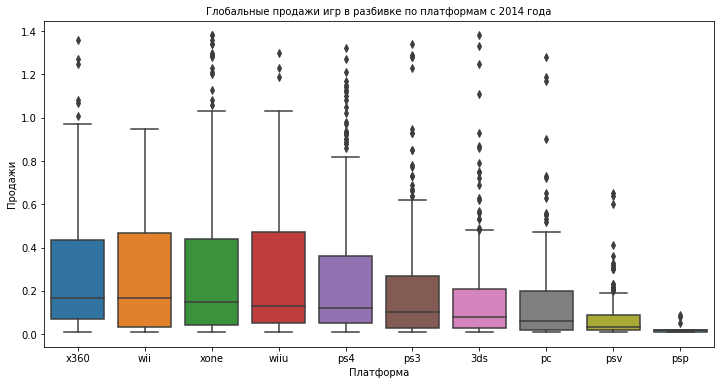

In [74]:
# Рассчитываем медиану продаж для каждой платформы
median_sales = data_top_platforms.groupby('platform')['sum_sales'].median().sort_values(ascending=False)

# Упорядочиваем платформы в порядке убывания медианы
ordered_platforms = median_sales.index

# Строим boxplot с указанием порядка
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_top_platforms, x='platform', y='sum_sales', order=ordered_platforms)
plt.title('Глобальные продажи игр в разбивке по платформам с 2014 года', fontsize=10)
plt.xlabel('Платформа', fontsize=10)
plt.ylabel('Продажи', fontsize=10)
plt.show()

Согласно медианному значению за последние два года мы видим, что Топ 5 самых популярных приставок это:
* x360
* wii
* xone
* wiiu
* ps4

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Тут согласен

Посмотрим как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков.

In [75]:
# Фильтруем данные по платформе x360
x360 = data[data['platform'] == 'x360']

# Проверяем кореляцию
correlation = x360['user_score'].corr(x360['sum_sales'])
print("Корреляция между user_score и sum_sales:", correlation.round(2))

Корреляция между user_score и sum_sales: 0.11


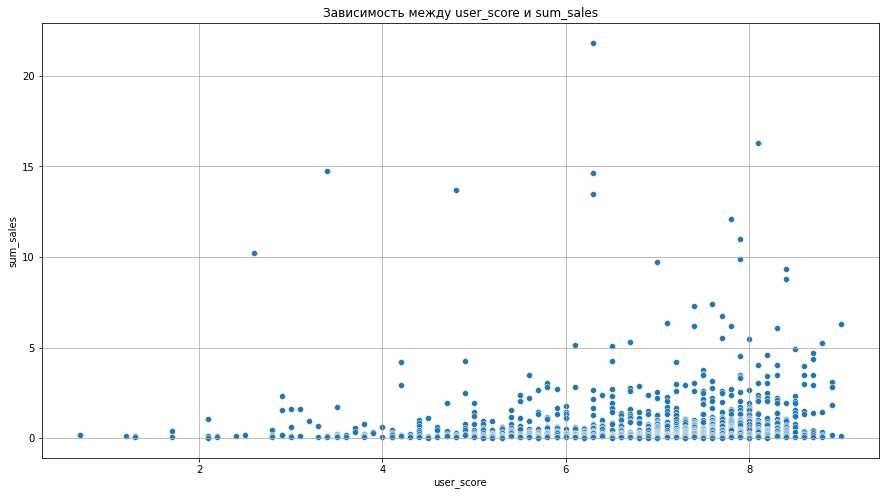

In [76]:
#Построим диаграмму рассеяния оценки пользователей и сумм продаж
plt.figure(figsize=(15,8))
sns.scatterplot(x='user_score', y='sum_sales', data=x360)
plt.title('Зависимость между user_score и sum_sales')
plt.grid(True)
plt.show()

In [77]:
#Корреляция между оценкой критиков и продажам
correlation = x360['critic_score'].corr(x360['sum_sales'])
print("Корреляция между critic_score и sum_sales:", correlation.round(2))

Корреляция между critic_score и sum_sales: 0.39


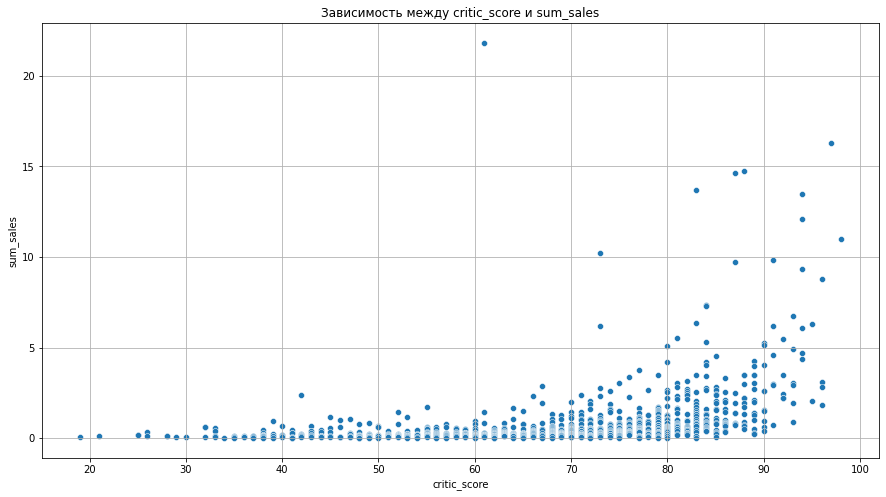

In [78]:
#Построим диаграмму рассеяния по оценкам критиков и сумм продаж
plt.figure(figsize=(15,8))
sns.scatterplot(x='critic_score', y='sum_sales', data=x360)
plt.title('Зависимость между critic_score и sum_sales')
plt.grid(True)
plt.show()

Получилось ожидаемо:
* Чем выше оценка пользователя, тем и больше сумма продаж
* Чем выше оценка критика, тем и больше сумма продаж


Степень влияния оценки на сумму продаж сравним между платформами.
_________

Теперь взглянем что можно сказать по играм на других топовых платформах.

In [79]:
#Функция для графиков рассеивания и поодсчета кореляции
list_top_platform =['ps2','x360','ps3','wii','ds']
def other_platform_matrix(name_of_platform):
    platform = data[data['platform']==name_of_platform]
    fig, ax = plt.subplots(1 ,2, figsize=(12,6))
    sns.scatterplot(x='user_score', y='sum_sales', data=platform, ax=ax[0])
    sns.scatterplot(x='critic_score', y='sum_sales', data=platform, ax=ax[1])
    fig.suptitle(name_of_platform, fontsize=15)
    ax[0].set(xlabel='Оценка пользователей')
    ax[1].set(xlabel='Оценка критиков')
    ax[0].set(ylabel='Кол-во продаж')
    ax[1].set(ylabel='Кол-во продаж')
    plt.show()
    
    correl = platform['user_score'].corr(platform['sum_sales']).round(2)
    critic_correl = platform['critic_score'].corr(platform['sum_sales']).round(2)
    
    #критик
    if 0.3 >= critic_correl >= 0.1:
        print('Корреляция между оценками критиков и продажами игр', name_of_platform, ': слабая', critic_correl)
    if 0.5 >= critic_correl >= 0.3:
        print('Корреляция между оценками критиков и продажами игр', name_of_platform, ': средняя', critic_correl)
    if 0.7 >= critic_correl >= 0.5:
        print('Корреляция между оценками критиков и продажами игр', name_of_platform, ': выше средней', critic_correl)
    if 0.9 >= critic_correl >= 0.7:
        print('Корреляция между оценками критиков и продажами игр', name_of_platform, ': высокая', critic_correl)
    if 1 >= critic_correl >= 0.9:
        print('Корреляция между оценками критиков и продажами игр', name_of_platform, ': сильная', critic_correl)
    #польз
    if 0.3 >= correl >= 0.1:
        print('Корреляция между оценками пользователей и продажами игр', name_of_platform, ': слабая', correl)
    if 0.5 >= correl >= 0.3:
        print('Корреляция между оценками пользователей и продажами игр', name_of_platform, ': средняя', correl)
    if 0.7 >= correl >= 0.5:
        print('Корреляция между оценками пользователей и продажами игр', name_of_platform, ': выше средней', correl)
    if 0.9 >= correl >= 0.7:
        print('Корреляция между оценками пользователей и продажами игр', name_of_platform, ': высокая', correl)
    if 1 >= correl >= 0.9:
        print('Корреляция между оценками пользователей и продажами игр', name_of_platform, ': сильная', correl)

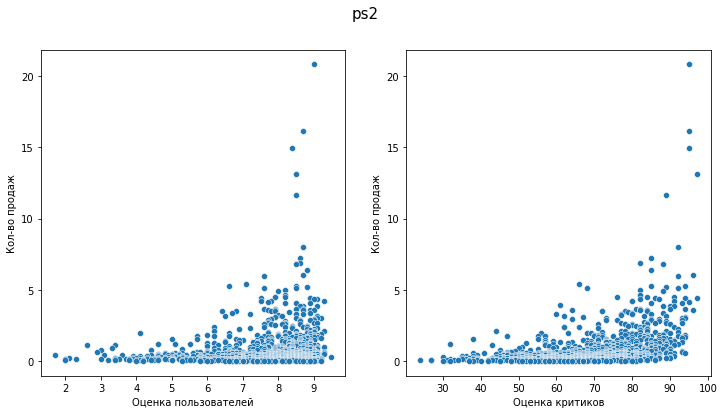

Корреляция между оценками критиков и продажами игр ps2 : средняя 0.4
Корреляция между оценками пользователей и продажами игр ps2 : слабая 0.17


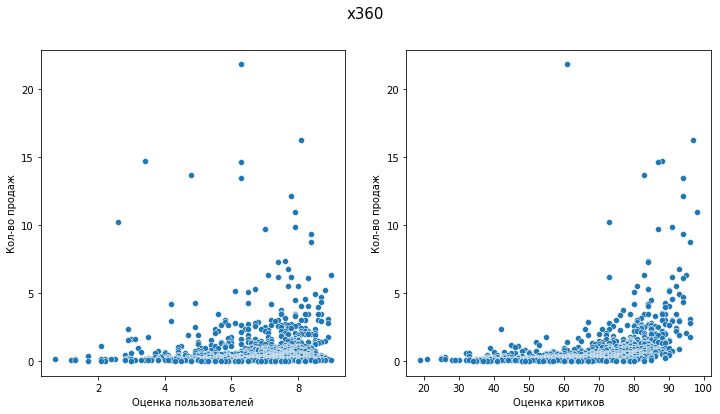

Корреляция между оценками критиков и продажами игр x360 : средняя 0.39
Корреляция между оценками пользователей и продажами игр x360 : слабая 0.11


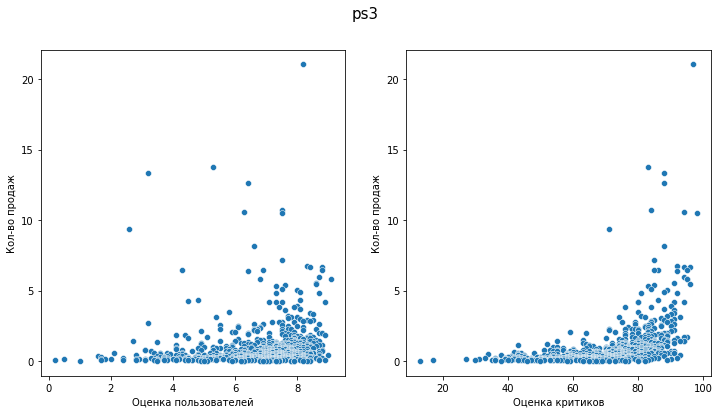

Корреляция между оценками критиков и продажами игр ps3 : средняя 0.43
Корреляция между оценками пользователей и продажами игр ps3 : слабая 0.13


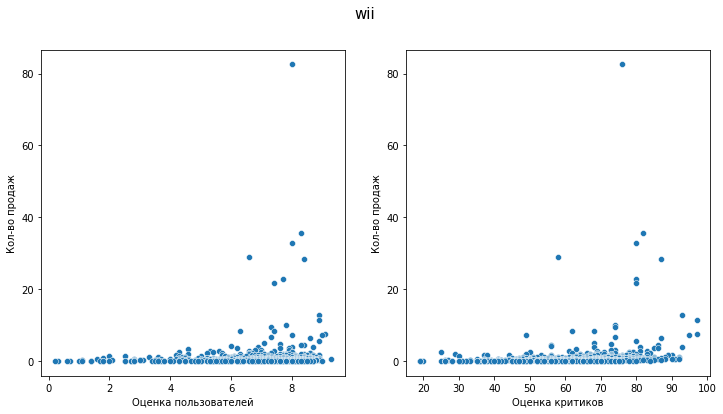

Корреляция между оценками критиков и продажами игр wii : слабая 0.18
Корреляция между оценками пользователей и продажами игр wii : слабая 0.11


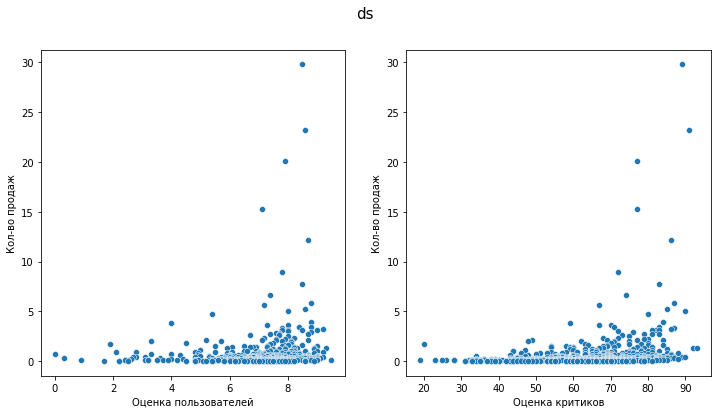

Корреляция между оценками критиков и продажами игр ds : слабая 0.24
Корреляция между оценками пользователей и продажами игр ds : слабая 0.13


In [80]:
for platform in list_top_platform:
    other_platform_matrix(platform)

Оценка пользователей и критиков не сильно влияет на продаж. 

Из топовых приставок ps2, x360, ps3 имеют более высокую корреляцию, между оценками пользователей и критиков к продажам, по сравнению с wii и ds.
_______

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Графики отличные. Верная интерпритация значений корреляции Пирсона. Ты молодец =)
</div>

Посмотрим на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами? (вопросы от заказчика)

In [81]:
game_genre = data.pivot_table(index='genre', values='sum_sales', aggfunc='sum').sort_values(by='sum_sales', ascending=False)
game_genre = game_genre.reset_index().rename_axis(None, axis=1)
game_genre

,genre,sum_sales
0,action,1744.17
1,sports,1331.26
2,shooter,1052.45
3,role-playing,934.56
4,platform,827.29
5,misc,802.51
6,racing,728.67
7,fighting,447.53
8,simulation,389.97
9,puzzle,242.57


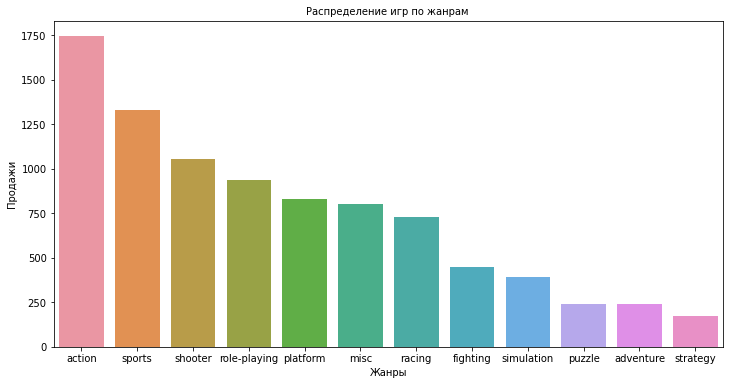

In [82]:
plt.figure(figsize=(12,6))
plt.title('Распределение игр по жанрам ',fontsize=10)
sns.barplot(data=game_genre, x='genre', y='sum_sales')
plt.xlabel('Жанры',fontsize=10)
plt.ylabel('Продажи',fontsize=10)
plt.show()

Общие продажи - не совсем точно нам дает понять что яляется наиболее прибыльным жанром. За высокими показателями общих продаж может скрываться множество мелких игр с низкими продажами. Или 2-3 звезды и куча провалов. Лучше найти жанр, где игры стабильно приносят высокий доход - для этого стоит рассмотреть средние или медианные продажи.

Посмотрим на распределение с помощью боксплота.

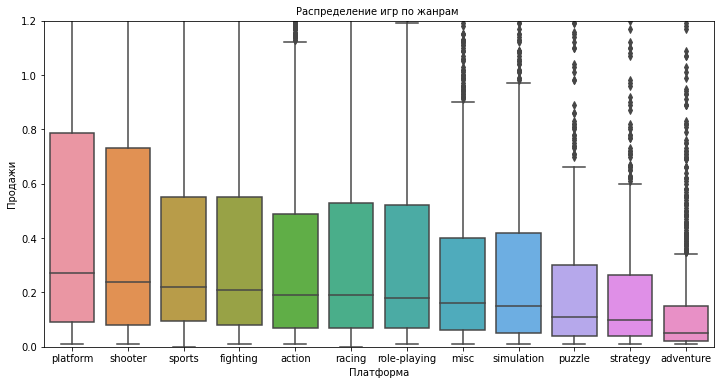

In [83]:
# Рассчитываем медиану продаж для каждого жанра
median_genre = data.groupby('genre')['sum_sales'].median().sort_values(ascending=False)

# Упорядочиваем платформы в порядке убывания медианы
ordered_genre = median_genre.index

# Строим boxplot с указанием порядка
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='genre', y='sum_sales', order=ordered_genre)
plt.title('Распределение игр по жанрам ', fontsize=10)
plt.ylim(0, 1.2)
plt.xlabel('Платформа', fontsize=10)
plt.ylabel('Продажи', fontsize=10)
plt.show()

* самые продаваемые игры жанра platform, shooter и sport
* самые непопулярные стратегии и приключения
_________

# Шаг 4. Составить портрет пользователя каждого региона

* Определить для пользователя каждого региона (NA, EU, JP):
    * Самые популярные платформы (топ-5). Описать различия в долях продаж.
    * Самые популярные жанры (топ-5). Пояснить разницу.
    * Влияет ли рейтинг ESRB на продажи в отдельном регионе? 
    
    (задачи от заказчика)


In [84]:
#Функция для создания сводбных таблиц
def region_func(row, title):
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
    for pivot, ax in zip(list(['platform','genre','rating']),axes.flatten()[:3]):
        ppivot = data.pivot_table(index=pivot, values=row, aggfunc='sum'
                  ).sort_values(by=row, ascending=False).reset_index().rename_axis(None, axis=1).head(5)
        print(ppivot)
        print('\n\n') 
        sns.set_palette("Blues")
        sns.barplot(data=ppivot, x=pivot, y=row, ax=ax)
        fig.suptitle(title, fontsize=15)
        
plt.show()
sns.set()

NA

  platform  na_sales
0     x360    602.47
1      ps2    583.84
2      wii    496.90
3      ps3    393.49
4       ds    382.40



      genre  na_sales
0    action    879.01
1    sports    684.43
2   shooter    592.24
3  platform    445.50
4      misc    407.27



  rating  na_sales
0      e   1292.99
1      t    759.75
2      m    748.48
3   e10+    353.32
4    k-a      2.56





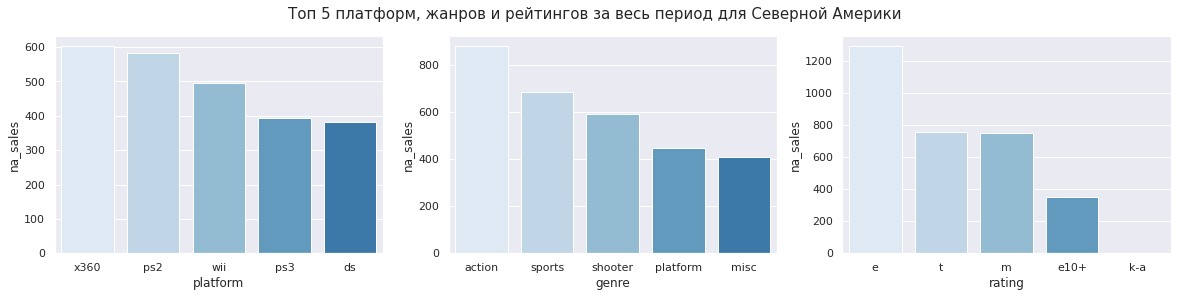

In [85]:
#Выведем топ 5 платформ, жанров и рейтингов по Северной Америке
region_func('na_sales','Топ 5 платформ, жанров и рейтингов за весь период для Северной Америки')

Вывод по Северной Америке:

* XBOX, PS2, WII, PS3, DS самые популярные игровые платформы;
* Топ 5 жанров: action, sports, shooter, platform, misc;
* Больше всего продаж у игр с рейтингом "для всех", затем игры с рейтингом "от 13 и выше" и после них с рейтингом "от 17 и выше".
_______

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Молодец, что визуализируешь полученные данные

EU

  platform  eu_sales
0      ps2    339.29
1      ps3    329.80
2     x360    270.76
3      wii    262.21
4       ps    213.61



     genre  eu_sales
0   action    519.13
1   sports    376.78
2  shooter    317.34
3   racing    236.51
4     misc    212.74



  rating  eu_sales
0      e    710.24
1      m    483.97
2      t    427.03
3   e10+    188.04
4     ao      0.61





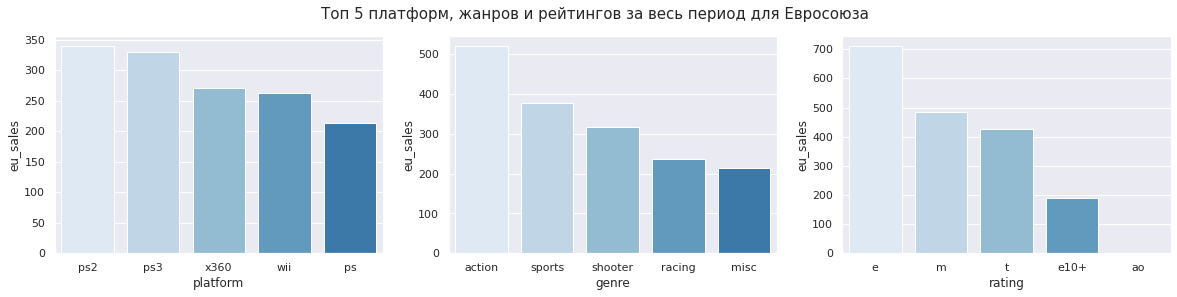

In [86]:
# Выведем топ 5 платформ, жанров и рейтингов для Евросоюза
region_func('eu_sales','Топ 5 платформ, жанров и рейтингов за весь период для Евросоюза')

Вывод по Евросоюзу:

* PS2, PS3, X360, WII, PS самые популярные игровые платформы;
* Топ 5 жанров: action, sports, shooter, racing, misc;
* Больше всего продаж у игр с рейтингом "для всех", затем игры с рейтингом "от 17 и выше" и после них с рейтингом "от 13 и выше".
________

JP

  platform  jp_sales
0       ds    175.57
1       ps    139.82
2      ps2    139.20
3     snes    116.55
4      3ds    100.67



          genre  jp_sales
0  role-playing    355.41
1        action    161.43
2        sports    135.54
3      platform    130.83
4          misc    108.11



  rating  jp_sales
0      e    198.11
1      t    151.40
2      m     64.24
3   e10+     40.20
4    k-a      1.46





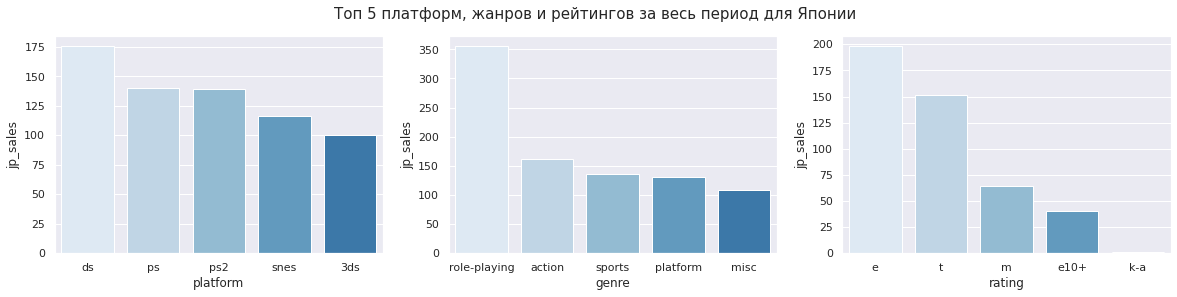

In [87]:
#Выведем топ 5 платформ, жанров и рейтингов для Японии
region_func('jp_sales','Топ 5 платформ, жанров и рейтингов за весь период для Японии')

Вывод по Японии:

* DS, PS, PS2, SNES, 3DS самые популярные игровые платформы;
* Топ 5 жанров: roleplaying, action, sports, platform, misc;
* Больше всего продаж у игр с рейтингом "для всех", затем игры с рейтингом "от 13 и выше" и после них с рейтингом "от 17 и выше".
________

Сравним портреты пользователей в зависимости от региона:

Северная Америка:
* XBOX, PS2, WII, PS3, DS самые популярные игровые платформы;
* Топ 5 жанров: action, sports, shooter, platform, misc;
* Больше всего продаж у игр с рейтингом "для всех", затем игры с рейтингом "от 13 и выше" и после них с рейтингом "от 17 и выше".

Евросоюз:
* PS2, PS3, X360, WII, PS самые популярные игровые платформы;
* Топ 5 жанров: action, sports, shooter, racing, misc;
* Больше всего продаж у игр с рейтингом "для всех", затем игры с рейтингом "от 17 и выше" и после них с рейтингом "от 13 и выше".

Япония:
* DS, PS, PS2, SNES, 3DS самые популярные игровые платформы;
* Топ 5 жанров: roleplaying, action, sports, platform, misc;
* Больше всего продаж у игр с рейтингом "для всех", затем игры с рейтингом "от 13 и выше" и после них с рейтингом "от 17 и выше".

Все регионы объединяет популярность игр с рейтингом "для всех" и весьма популярны спортивные игры.  
_______




**Возьмем те же данные, но с 2014 года**

In [88]:
#Функция для создания сводных таблиц за период с 2014 г
def for_2014(row, title):
    temp = data[data['year_of_release']>=2014]
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
    for pivot, ax in zip(list(['platform','genre','rating']), axes.flatten()[:3]):
        ppivot = temp.pivot_table(index=pivot, values=row, aggfunc='sum').sort_values(by=row, ascending=False).reset_index().rename_axis(None, axis=1).head(5)
        print(ppivot)
        print('\n\n')
        sns.set_palette("BuGn_r")
        sns.barplot(data=ppivot, x=pivot, y=row, ax=ax)
        fig.suptitle(title, fontsize=15)

  platform  na_sales
0      ps4     98.61
1     xone     81.27
2     x360     28.30
3      3ds     22.64
4      ps3     22.05



          genre  na_sales
0       shooter     79.02
1        action     72.59
2        sports     46.13
3  role-playing     33.47
4          misc     15.05



  rating  na_sales
0      m     96.48
1      e     50.74
2      t     38.95
3   e10+     33.23





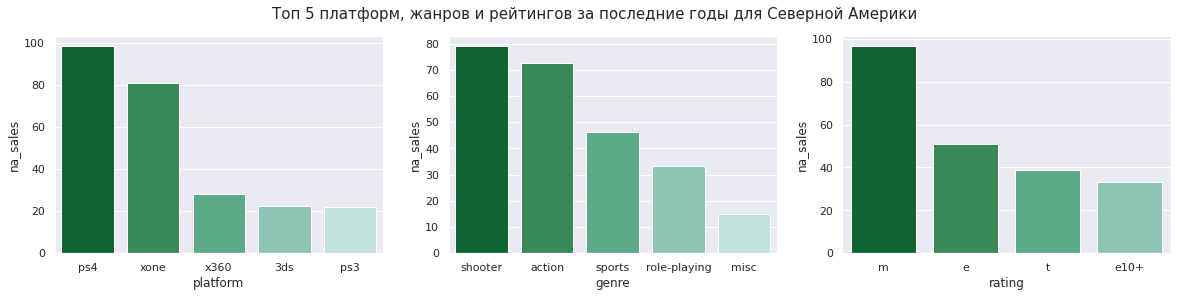

In [89]:
for_2014('na_sales','Топ 5 платформ, жанров и рейтингов за последние годы для Северной Америки')

За последние два года портрет пользователя в Северной Америке:

* PS4, X ONE, X360, 3DS, PS3 самые популярные игровые платформы;
* Топ 5 жанров: shooter, action,sports, roleplaying, misc;
* Больше всего продаж у игр с рейтингом "от 17 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 13 и выше".


  platform  eu_sales
0      ps4    130.04
1     xone     46.25
2      ps3     25.54
3       pc     18.22
4      3ds     16.12



          genre  eu_sales
0        action     74.93
1       shooter     65.52
2        sports     45.73
3  role-playing     28.17
4        racing     14.13



  rating  eu_sales
0      m     93.69
1      e     58.06
2      t     34.07
3   e10+     26.16





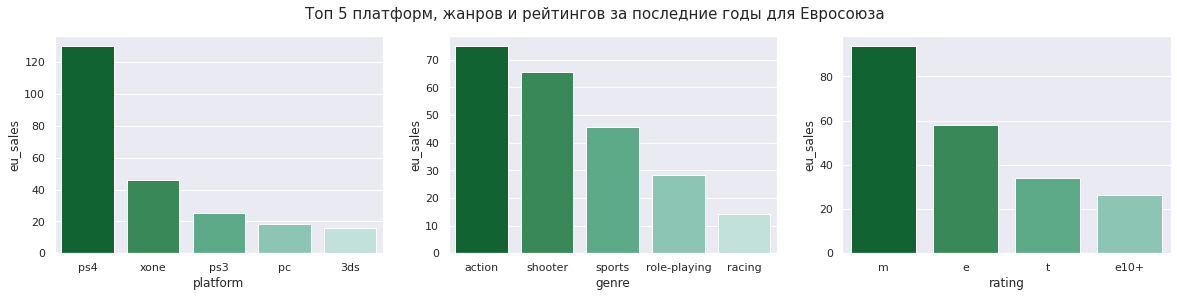

In [90]:
for_2014('eu_sales','Топ 5 платформ, жанров и рейтингов за последние годы для Евросоюза')

За последние два года портрет пользователя для  Евросоюза:

* PS4, X ONE, PS3, PC, 3DS самые популярные игровые платформы;
* Топ 5 жанров: action, shooter, sports,roleplaying, racing;
* Больше всего продаж у игр с рейтингом "от 17 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 13 и выше".


  platform  jp_sales
0      3ds     44.24
1      ps4     15.02
2      psv     14.54
3      ps3     11.22
4     wiiu      7.31



          genre  jp_sales
0  role-playing     31.16
1        action     29.58
2      fighting      6.37
3          misc      5.61
4       shooter      4.87



  rating  jp_sales
0      t     14.78
1      e      8.94
2      m      8.01
3   e10+      4.46





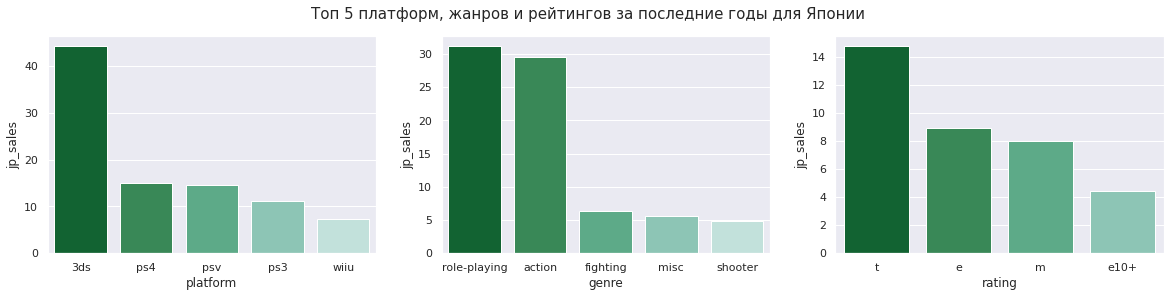

In [91]:
for_2014('jp_sales','Топ 5 платформ, жанров и рейтингов за последние годы для Японии')

За последние два года портрет пользователя для Японии:

* 3DS, PS4, PSV, PS3, WIIU самые популярные игровые платформы;
* Топ 5 жанров: roleplaying, action, fighting, misc,shooter;
* Больше всего продаж у игр с рейтингом "от 13 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 17 и выше".


Портрет пользователя за последние 2 года немного поменялся: 


- Северная Америка:

* PS4, X ONE, X360, 3DS, PS3 самые популярные игровые платформы;
* Топ 5 жанров: shooter, action,sports, roleplaying, misc;
* Больше всего продаж у игр с рейтингом "от 17 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 13 и выше".


- Евросоюз:

* PS4, X ONE, PS3, PC, 3DS самые популярные игровые платформы;
* Топ 5 жанров: action, shooter, sports,roleplaying, racing;
* Больше всего продаж у игр с рейтингом "от 17 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 13 и выше".


- Японии:

* 3DS, PS4, PSV, PS3, WIIU самые популярные игровые платформы;
* Топ 5 жанров: roleplaying, action, fighting, misc,shooter;
* Больше всего продаж у игр с рейтингом "от 13 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 17 и выше".


PS4 набирает популярность в проанализированных регионах, жанр экшн также весьма популярен везде за последние годы.
______

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Верная интерптеация полученных данных. Так держать!)

# Шаг 5. Проверить гипотезы

* Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
* Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.
* Задать самостоятельно пороговое значение alpha. Пояснить:
* Как вы сформулировали нулевую и альтернативную гипотезы;
* Какой критерий применили для проверки гипотез и почему.
_____

In [92]:
# Сохраним данные по группам
x_one = data_top_platforms[(data_top_platforms['platform']=='xone') & (data_top_platforms['year_of_release']>=2014)]['user_score']
pc = data_top_platforms[(data_top_platforms['platform']=='pc') & (data_top_platforms['year_of_release']>=2014)]['user_score']

In [93]:
#средний рейтинг пользователя
print('Средний рейтинг пользователя Xbox One:', x_one.mean().round(4))
print('Средний рейтинг пользователя PC:', pc.mean().round(4))

Средний рейтинг пользователя Xbox One: 6.6454
Средний рейтинг пользователя PC: 6.3361


В рассматриваемых группах средний рейтинг различается, нам надо сформулировать гипотезы от обратного и провести тестирование, чтобы понять насколько мы имеем случайные выборки или наоборот неслучайные. Установим стд порго стат значимости в 5%. 

Для наших данных (сравниение средних значений двух независимых числовых групп с нормальным распределением) подойдет Т-тест


Сформулируем гипотезы:

* Нулевая гипотеза: средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
* Альтернативная гипотеза: средние пользовательские рейтинги платформ Xbox One и PC различаются.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Гипотезы верные. Отлично!
</div>

In [94]:
#Выполним A/B тест методом ttest_ind

alpha = 0.05 

results = st.ttest_ind(x_one.dropna(), pc.dropna(), equal_var=False)
print('p-значение:', results.pvalue.round(4))


if (results.pvalue < alpha):
    print("Отклоняем нулевую гипотезу: средние пользовательские рейтинги платформ Xbox One и PC различаются")
else:
    print("Не получилось отклонить нулевую гипотезу: средние пользовательские рейтинги платформ Xbox One и PC одинаковые")

p-значение: 0.1108
Не получилось отклонить нулевую гипотезу: средние пользовательские рейтинги платформ Xbox One и PC одинаковые


С установленным уровнем стат значимости в 5% у нас не достаточно оснований для отклонения нулевой гипотезы. 

Статистический тест нам указал, что вероятность получить данные о равенстве средних значений в обоих группах весьма высокий и следовательно мы считаем что средние значения равны. 
______

Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

In [95]:
# Делим на группы с пользовательскими оценками
genre_action = data[(data['genre']=='action') & (data['year_of_release']>=2014)]['user_score']
genre_sports = data[(data['genre']=='sports') & (data['year_of_release']>=2014)]['user_score']

In [96]:
#средний рейтинг пользователя
print('Средний рейтинг пользователя жанр action:', genre_action.mean().round(4))
print('Средний рейтинг пользователя жанр sports:', genre_sports.mean().round(4))

Средний рейтинг пользователя жанр action: 6.7664
Средний рейтинг пользователя жанр sports: 5.2252


В рассматриваемых группах средний рейтинг различается, нам надо сформулировать гипотезы от обратного и провести тестирование, чтобы понять насколько мы имеем случайные выборки или наоборот неслучайные. Установим стд порго стат значимости в 5%.

Для наших данных (сравниение средних значений двух независимых числовых групп с нормальным распределением) подойдет Т-тест

Сформулируем гипотезы:

* Нулевая гипотеза: средние пользовательские рейтинги двух жанров одинаковые;
* Альтернативная гипотеза: средние пользовательские рейтинги двух жанров различаются.

In [97]:
#Выполним A/B тест методом ttest_ind

alpha = 0.05 

results = st.ttest_ind(genre_action.dropna(), genre_sports.dropna(), equal_var=False)
print('p-значение:', results.pvalue)


if (results.pvalue < alpha):
    print("Отклоняем нулевую гипотезу: средние пользовательские рейтинги двух жанров различаются")
else:
    print("Не получилось отклонить нулевую гипотезу: средние пользовательские рейтинги двух жанров одинаковые")

p-значение: 9.658176026869598e-15
Отклоняем нулевую гипотезу: средние пользовательские рейтинги двух жанров различаются


По результатам тестирования мы получили супер маленькое значение p-value, которое однозначно отвергает Нулевую гипотезу. 

Низкое значение по результатам теста указывает, что у нас практически нет шансов получить одинакове средние рейнтинги по двум жанрам.
____________

# Шаг 6. Написать общий вывод

Перед анализом данных, мы подготовили наши данные, привели к правильным данным колонки, а конкретней привели к нижнему регистру наименования колонок и часть данных.

Проведя анализ, мы выявили, что количество игр на игровые приставки и компьютеры начало расти с большой скоростью с 1993 года до 2008 года. С 2008 года после того как сфера игр стала массово популяризироваться произошел спад разработок игр.

Самыми популярными оказались следующие приставки: PS2, X360, PS3, WII, DS, PS.

Также мы выявили, что средняя продолжительность жизни игровой приставки с10 лет. 
Около 5 лет после выпуска консоли уходит на развитие ее максимальной популярности. 


Мы провели анализ оценок пользователей и критиков. Заметили, что оценки критиков и пользователей взаимосвязаны с продажами самих игр. То есть чем больше оценка критиков или пользователей, тем лучше продажа игры.
Так же определили, что самый популярный жанр за все время это Экшн. На последнем месте стратегии.

После мы составили портреты пользователей каждого региона.

* В Северной америке:
    * самые популярные жанры это action, sports, shooter. 
    * Игровые приставки : XBOX, PS2 и WII. 
    * А по рейтингу игр люди предпочитают игры с рейтингами: "для всех", "от 13 и выше" и "от 17 и выше".

* В Европе:
    * популярные жанры точно такие же как и в Северной Америке. 
    * Но приставки по предпочитают по следующей очередности: PS2, PS3, XBOX. 
    * Рейтинг игр отличается лишь вторым местом, на втором месте у них от 17 и выше, а на третьем 13 и выше.


* В Японии: 
    * предпочитают игровые приставки: DS, PS, PS2.
    * жанры игры : Role-playing, action и sports. 
    * Рейтинг игр аналогичный Северной Америке.

* самые продаваемые игры жанра platform, shooter и sport
* самые непопулярные стратегии и приключения

**В связи быстроменяющимися тенденциями в области создания компьютерных игр мы акцентировали внимние на анализе относительно недавних тенденций и давая прогноз на 2017 год мы проанализировали данные с 2014 года:**

Топ 5 самых популярных приставок с этого времени:
* x360
* wii
* xone
* wiiu
* ps4

Портреты пользователя за последнее время также немного изменились:

- Северная Америка:

* PS4, X ONE, X360, 3DS, PS3 самые популярные игровые платформы;
* Топ 5 жанров: shooter, action,sports, roleplaying, misc;
* Больше всего продаж у игр с рейтингом "от 17 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 13 и выше".


- Евросоюз:

* PS4, X ONE, PS3, PC, 3DS самые популярные игровые платформы;
* Топ 5 жанров: action, shooter, sports,roleplaying, racing;
* Больше всего продаж у игр с рейтингом "от 17 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 13 и выше".


- Японии:

* 3DS, PS4, PSV, PS3, WIIU самые популярные игровые платформы;
* Топ 5 жанров: roleplaying, action, fighting, misc,shooter;
* Больше всего продаж у игр с рейтингом "от 13 и выше", затем игры с рейтингом "для всех" и после них с рейтингом "от 17 и выше".


PS4 набирает популярность в проанализированных регионах, жанр экшн и стрелялки также весьма популярен везде за последние годы.
______



Также мы провели A/B тестирование в результате которых доказали:
* средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
* средние пользовательские рейтинги жанров Action и Sports различаются.


Таким образом, предполагаем, что лучше всего продавать игры для таких приставок как Sony Playstation 4
Жанр action и shooter, а тажке выбирать игры с рейтингом "от 17 и выше", тогда продажи будут значительно больше, чем если продавать другие игры.
